In [1]:
import cupy as cp
import numpy as np
from scipy.sparse import coo_matrix
import math

def label_propagation(X, y_label, alpha=0.5, max_iter=1000):
    """标签传播算法的GPU加速版本"""
    n_samples = X.shape[0]
    n_classes = y_label.shape[1]
    
    # 一次性将所有数据转移到GPU
    with cp.cuda.Device(0):
        # 先将COO矩阵转换为CSR格式
        X_csr = X.tocsr()
        
        # 构建相似度矩阵W (使用CSR格式)
        W = cp.sparse.csr_matrix(
            (cp.exp(-alpha * cp.array(X_csr.data) ** 2),
             cp.array(X_csr.indices),
             cp.array(X_csr.indptr)),
            shape=X.shape
        )
        
        # 将标签转换为概率分布格式
        Y = cp.array(y_label, dtype=cp.float32)
        Y_old = cp.zeros_like(Y)
        y_label_gpu = cp.array(y_label)
        
        # 对未标记的样本初始化为均匀分布
        unlabeled_mask = ~(y_label_gpu != -1).any(axis=1)
        Y[unlabeled_mask] = 1.0 / n_classes
        
        # 主循环
        for _ in range(max_iter):
            Y_old = Y.copy()
            
            # 标签传播
            Y = W.dot(Y)
            
            # 按行归一化
            row_sums = Y.sum(axis=1).reshape(-1, 1)
            Y = Y / cp.maximum(row_sums, 1e-12)
            
            # 保持已标记样本不变
            labeled_mask = (y_label_gpu != -1).any(axis=1)
            Y[labeled_mask] = y_label_gpu[labeled_mask]
            
            # 检查收敛
            diff = cp.abs(Y - Y_old).sum() / n_samples
            if _ > 0 and diff < 1e-5:
                break
        
        # 获取预测结果（转换为单一标签）
        y_pred = cp.zeros(n_samples, dtype=cp.int32)
        for i in range(n_samples):
            if cp.any(Y[i] > 0):  # 只处理有效的预测
                y_pred[i] = cp.argmax(Y[i])
            else:
                y_pred[i] = 0  # 默认标签
                
        return cp.asnumpy(y_pred)

def data_process(y_old, preserved=0.8, changed=0.1, masked=0.1):
    """数据预处理函数"""
    n_samples, n_classes = y_old.shape
    y_new = np.full_like(y_old, -1, dtype=np.float32)
    
    # 只处理有标签的样本
    labeled_mask = (y_old != -1).any(axis=1)
    labeled_indices = np.where(labeled_mask)[0]
    
    for idx in labeled_indices:
        r = np.random.random()
        if r < preserved:
            # 保持原标签
            y_new[idx] = y_old[idx]
        elif r < preserved + changed:
            # 随机选择一个不同的标签
            current_label = np.argmax(y_old[idx])
            possible_labels = list(range(n_classes))
            possible_labels.remove(current_label)
            if possible_labels:
                new_label = np.random.choice(possible_labels)
                y_new[idx] = np.zeros(n_classes)
                y_new[idx, new_label] = 1
    
    return y_new

def rectify(X, y_label, y_pred):
    """结果修正函数"""
    with cp.cuda.Device(0):
        X_gpu = cp.sparse.csr_matrix(X)
        y_pred_gpu = cp.array(y_pred)
        y_new = cp.array(y_pred.copy())
        
        # 获取需要修正的样本
        labeled_mask = cp.array(y_label != -1).any(axis=1)
        labeled_indices = cp.where(labeled_mask)[0]
        
        # 使用字典统计邻居标签
        for i in labeled_indices:
            row = X_gpu[int(i)]
            if row.nnz > 0:
                # 获取邻居标签并统计
                neighbor_labels = y_pred_gpu[row.indices]
                labels, counts = cp.unique(neighbor_labels, return_counts=True)
                if len(counts) > 0:
                    # 选择最频繁的标签
                    max_idx = cp.argmax(counts)
                    y_new[int(i)] = labels[max_idx]
        
        return cp.asnumpy(y_new) 

d:\anaconda3\envs\pytorch\lib\site-packages\anndata\_core\anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
d:\anaconda3\envs\pytorch\lib\site-packages\scanpy\preprocessing\_pca.py:377: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  warn(msg, FutureWarning)
C:\Users\86153\AppData\Local\Temp\ipykernel_13456\61707549.py:62: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, key_added='clusters', resolution=lores)


Candidates Generated.
Epoch 1/50, Loss: 13.6817
Epoch 2/50, Loss: 6.2641
Epoch 3/50, Loss: 4.7514
Epoch 4/50, Loss: 3.8875
Epoch 5/50, Loss: 3.3488
Epoch 6/50, Loss: 2.7054
Epoch 7/50, Loss: 2.4588
Epoch 8/50, Loss: 2.1319
Epoch 9/50, Loss: 2.2226
Epoch 10/50, Loss: 2.3241
Epoch 11/50, Loss: 2.0029
Epoch 12/50, Loss: 2.0818
Epoch 13/50, Loss: 1.7976
Epoch 14/50, Loss: 1.2025
Epoch 15/50, Loss: 1.6153
Epoch 16/50, Loss: 1.5750
Epoch 17/50, Loss: 1.3209
Epoch 18/50, Loss: 1.4378
Epoch 19/50, Loss: 1.2193
Epoch 20/50, Loss: 1.4088
Epoch 21/50, Loss: 1.1139
Epoch 22/50, Loss: 0.9774
Epoch 23/50, Loss: 1.3786
Epoch 24/50, Loss: 1.4253
Epoch 25/50, Loss: 1.1962
Epoch 26/50, Loss: 1.0302
Epoch 27/50, Loss: 0.9341
Epoch 28/50, Loss: 0.9514
Epoch 29/50, Loss: 0.8891
Epoch 30/50, Loss: 0.9157
Epoch 31/50, Loss: 0.8790
Epoch 32/50, Loss: 0.9256
Epoch 33/50, Loss: 0.9443
Epoch 34/50, Loss: 0.8226
Epoch 35/50, Loss: 0.7619
Epoch 36/50, Loss: 0.7818
Epoch 37/50, Loss: 0.7245
Epoch 38/50, Loss: 0.821

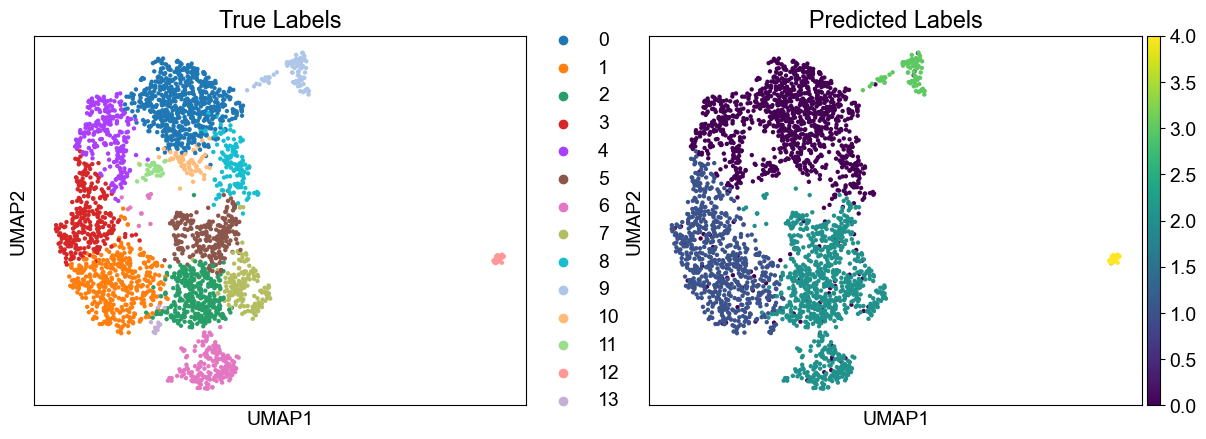

Final ARI Score: 0.4072


In [ ]:
import scanpy as sc
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import adjusted_rand_score
import random
import matplotlib.pyplot as plt
from LPA import label_propagation  # 导入自定义的 LPA 函数
from scipy.sparse import csr_matrix

# 路径设置
data_path = r"D:\Desktop\机器学习\大作业\24机器学习大作业\24机器学习大作业\data\dataset.h5ad"

# VAE 模型定义
class VAE(nn.Module):
    def __init__(self, input_size, output_size, h_dim=400, z_dim=20):
        super(VAE, self).__init__()
        self.fc1 = nn.Linear(input_size, h_dim)
        self.batch_norm1 = nn.BatchNorm1d(h_dim)
        self.fc2 = nn.Linear(h_dim, z_dim)
        self.fc3 = nn.Linear(h_dim, z_dim)
        self.fc4 = nn.Linear(z_dim, h_dim)
        self.batch_norm2 = nn.BatchNorm1d(h_dim)
        self.fc5 = nn.Linear(h_dim, output_size)

    def encode(self, x):
        h = F.relu(self.fc1(x))
        h = self.batch_norm1(h)
        return self.fc2(h), self.fc3(h)

    def reparameterize(self, mu, log_var):
        std = torch.exp(log_var / 2)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = F.relu(self.fc4(z))
        h = self.batch_norm2(h)
        return torch.sigmoid(self.fc5(h))

    def forward(self, x):
        mu, log_var = self.encode(x)
        z = self.reparameterize(mu, log_var)
        x_reconst = self.decode(z)
        return x_reconst, mu, log_var

# 数据预处理与候选集生成
def Gen_TrainSet(h5adFile):
    adata = sc.read_h5ad(h5adFile)
    sc.pp.normalize_total(adata, inplace=True)
    sc.pp.log1p(adata)
    sc.pp.highly_variable_genes(adata, flavor='seurat', inplace=True)
    sc.pp.pca(adata, n_comps=50, use_highly_variable=True, svd_solver='arpack')
    sc.pp.neighbors(adata)
    sc.tl.umap(adata)

    candidates = pd.DataFrame(index=adata.obs_names)
    for res in range(1, 10, 2):
        lores = res * 0.1
        sc.tl.leiden(adata, key_added='clusters', resolution=lores)
        tmp_can = pd.DataFrame(
            np.array([adata.obs['clusters'] == x for x in adata.obs['clusters'].unique()]).T,
            index=adata.obs_names)
        candidates = pd.concat([candidates, tmp_can], axis=1)
    return adata, candidates

# 标签遮蔽与错误标签生成
def Gen_maskSet(candidate: pd.DataFrame, errRate=0.20):
    """
    根据候选集生成一维标签数组（适配 LabelPropagation）
    """
    # 初始化标签为 -1（未知）
    labels = np.full(candidate.shape[0], -1, dtype=int)

    # 随机选择一些样本为已知标签
    known_indices = random.sample(range(candidate.shape[0]), int(candidate.shape[0] * (1 - errRate)))

    for idx in known_indices:
        # 找到行中第一个 True 的列索引作为标签
        row = candidate.iloc[idx]
        if row.any():
            labels[idx] = row.idxmax()

    return labels

# 使用 VAE 训练
def train_VAE(candidates, h_dim=400, z_dim=20, num_epochs=50, learning_rate=1e-3, batch_size=128):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    input_size = candidates.shape[1]
    model = VAE(input_size=input_size, output_size=input_size, h_dim=h_dim, z_dim=z_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    candidates_np = candidates.to_numpy(dtype=np.float32)
    dataset_size = candidates_np.shape[0]

    for epoch in range(num_epochs):
        # 按批次处理数据
        for start in range(0, dataset_size, batch_size):
            end = min(start + batch_size, dataset_size)
            batch_candidates = candidates_np[start:end]

            # 修复遮蔽矩阵维度
            mask_candidates = np.zeros_like(batch_candidates, dtype=np.float32)
            known_indices = random.sample(range(batch_candidates.shape[0]), int(batch_candidates.shape[0] * 0.95))
            mask_candidates[known_indices] = batch_candidates[known_indices]

            # 转换为张量
            mask_x = torch.tensor(mask_candidates, dtype=torch.float32).to(device)
            origin_x = torch.tensor(batch_candidates, dtype=torch.float32).to(device)

            # 前向传播
            reconst_x, mu, log_var = model(mask_x)
            reconst_loss = F.binary_cross_entropy(reconst_x, origin_x, reduction='mean')
            kl_div = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
            loss = reconst_loss + kl_div

            # 反向传播与优化
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        print(f"Epoch {epoch + 1}/{num_epochs}, Loss: {loss.item():.4f}")

    return model

def to_one_hot(y, n_classes):
    """将标签转换为 one-hot 编码"""
    return np.eye(n_classes)[y]

# 标签传播训练 (使用自定义的 label_propagation)
def train_LPA(candidate, adata, errRate=0.05):
    """
    使用自定义的标签传播算法训练并预测标签
    """
    X = adata.obsm['X_pca']  # 特征矩阵
    y = Gen_maskSet(candidate, errRate)  # 生成一维标签

    # 获取有标签的类别数
    n_classes = len(np.unique(y[y != -1]))
    if n_classes == 0:
        raise ValueError("No labeled data available.")

    # 将标签转换为 one-hot 编码，未标记的样本保持为全0
    y_one_hot = np.zeros((len(y), n_classes), dtype=np.float32)
    labeled_indices = y != -1
    y_one_hot[labeled_indices, y[labeled_indices]] = 1.0

    print(f"X shape: {X.shape}, y_one_hot shape: {y_one_hot.shape}")

    # 使用 adata 的邻接矩阵作为 W
    W = adata.obsp['connectivities'].copy()

    print(f"W shape: {W.shape}, Y shape: {y_one_hot.shape}")

    y_pred = label_propagation(W, y_one_hot)  # 使用自定义 LPA

    return y_pred

# 计算 ARI
def calculate_ARI(true_labels, predicted_labels):
    ari_score = adjusted_rand_score(true_labels, predicted_labels)
    print(f"ARI Score: {ari_score:.4f}")
    return ari_score

# 可视化结果
def visualize_result(adata, true_labels, predicted_labels):
    adata.obs["True Labels"] = true_labels
    adata.obs["Predicted Labels"] = predicted_labels
    sc.pl.umap(adata, color=["True Labels", "Predicted Labels"])

# 主函数
if __name__ == "__main__":
    adata, candidates = Gen_TrainSet(data_path)
    print("Candidates Generated.")

    vae_model = train_VAE(candidates)
    print("VAE Training Complete.")

    y_pred = train_LPA(candidates, adata)
    print("Label Propagation Training Complete.")

    true_labels = adata.obs["clusters"]
    ari_score = calculate_ARI(true_labels, y_pred)

    visualize_result(adata, true_labels, y_pred)
    print(f"Final ARI Score: {ari_score:.4f}")

In [2]:
# evaluation the robustness of LPA
import h5py
import scipy.sparse
import time
import random
import numpy as np
import pandas as pd
from sklearn.metrics.cluster import adjusted_rand_score
import LPA  # 导入新的LPA模块

df = pd.DataFrame(columns=['MR', 'ARI_o', 'ARI_r', 'Time'])

start = time.time()
# 读取数据集
with h5py.File(r"D:\Desktop\机器学习\大作业\LPA\dataset.h5ad", 'r') as f:
    group = f['obsp']['connectivities']
    data = group['data'][:]
    indices = group['indices'][:]
    indptr = group['indptr'][:]
    shape = (f['obsp']['connectivities'].attrs['shape'][0],
            f['obsp']['connectivities'].attrs['shape'][1])
    
    # 创建稀疏矩阵
    mat = scipy.sparse.csr_matrix((data, indices, indptr), shape=shape)
    coo = mat.tocoo()

# 读取标注数据
with h5py.File(r"D:\Desktop\机器学习\大作业\LPA\dataset.h5ad", 'r') as h5file:
    obs_group = h5file['obs']
    if "codes" in obs_group['annotation']:
        annotations = obs_group['annotation']['codes'][:]
    else:
        annotations = obs_group['annotation'][:]

# 构建标签映射
unique_labels = np.unique(annotations)
label_to_idx = {label: idx for idx, label in enumerate(unique_labels)}
n_classes = len(unique_labels)

k1 = 1.0
while True:
    for _ in range(100):
        # 准备稀疏矩阵X
        X = scipy.sparse.coo_matrix((coo.data, (coo.row, coo.col)), 
                                  shape=(shape[0], shape[0]))
        
        # 准备标签矩阵
        y_label = np.full((shape[0], n_classes), -1, dtype=np.float32)
        
        # 随机选择10%的样本作为已标记数据
        random_indices = random.sample(range(shape[0]), int(shape[0] * 0.1))
        for idx in random_indices:
            label_idx = label_to_idx[annotations[idx]]
            y_label[idx] = np.zeros(n_classes)
            y_label[idx, label_idx] = 1
            
        # 数据处理
        start_time = time.perf_counter()
        y_new = LPA.data_process(y_label, preserved=k1, changed=(1-k1), masked=0)
        
        # 标签传播
        y_pred = LPA.label_propagation(X, y_new, alpha=0.5, max_iter=1000)
        
        # 结果修正
        y_res = LPA.rectify(X, y_label, y_pred)
        
        end_time = time.perf_counter()
        execution_time = end_time - start_time
        
        # 计算ARI分数
        ari_o = adjusted_rand_score(annotations, y_pred)
        ari_r = adjusted_rand_score(annotations, y_res)
        
        # 记录结果
        item = [round((1-k1), 2), ari_o, ari_r, round(execution_time, 5)]
        print(item)
        df.loc[len(df)] = item
        
    k1 -= 0.05
    print(f"k1: {k1}")
    if k1 < 0:
        break

# 保存结果
df.to_csv("mistake.tsv", sep='\t', header=True, index=True)
end = time.time()
print(f"Total time: {end-start}")

[0.0, 0.8351735952734252, 0.8243229635239879, 13.11173]
[0.0, 0.8064363263773737, 0.7935337435212484, 0.87138]
[0.0, 0.7998356658674929, 0.7839582652215397, 0.88223]
[0.0, 0.7939697163727103, 0.7798691232622313, 0.86481]
[0.0, 0.7570537159370404, 0.7425352566155456, 0.78354]
[0.0, 0.836700797660099, 0.8251851426009627, 0.83969]
[0.0, 0.7931665762745224, 0.7820999660975708, 0.8766]
[0.0, 0.8178265091345974, 0.8028195969021906, 0.90341]
[0.0, 0.7765583850755998, 0.7644535904874761, 0.92031]
[0.0, 0.8064871396625677, 0.7933850900626248, 0.85653]
[0.0, 0.8360382989482208, 0.822873281677782, 0.86654]
[0.0, 0.842011865380043, 0.8268352931800421, 0.93438]
[0.0, 0.8380959667726565, 0.8265068412927663, 0.87213]
[0.0, 0.801599654085183, 0.7912475301571925, 0.80681]
[0.0, 0.8425008729014497, 0.8310252392177548, 0.8389]
[0.0, 0.8484021681708912, 0.836870382193784, 0.91058]
[0.0, 0.8424360390065679, 0.8309524039993552, 0.84645]
[0.0, 0.8125585696682474, 0.8019779105908179, 0.83795]
[0.0, 0.81467299

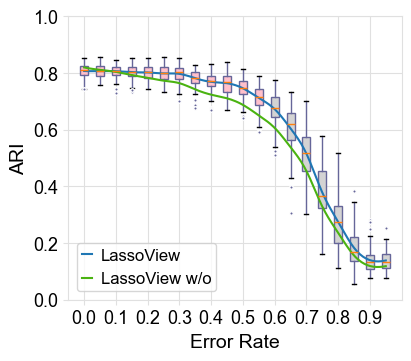

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.interpolate import make_interp_spline
plt.rcParams["font.sans-serif"] = ["Arial"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.size"] = 14


df = pd.read_csv("mistake.tsv", sep='\t', index_col=0)
mistakes = pd.DataFrame()
mistakes_wo = pd.DataFrame()
groups = df.groupby('MR')
for group in groups:
    mistakes[group[0]] = group[1]['ARI_r'].reset_index(drop=True)
    mistakes_wo[group[0]] = group[1]['ARI_o'].reset_index(drop=True)
x = np.arange(len(mistakes.columns))+1
y = list(mistakes.mean(axis=0))
y_wo = list(mistakes_wo.mean(axis=0))
x_smooth = np.linspace(x.min(), x.max(), 200)
y_smooth = make_interp_spline(x, y)(x_smooth)
y_smooth_wo = make_interp_spline(x, y_wo)(x_smooth)
fig, ax = plt.subplots(figsize=(4,3.5), constrained_layout=True)
bp = ax.boxplot(mistakes, sym='.', patch_artist=True)
plt.setp(bp['whiskers'], color='#666699')
plt.setp(bp['fliers'], markerfacecolor='#666699', markeredgecolor='white', marker='.', markersize=5)
colors = ['pink' if s > 0.7 else 'lightgrey' for s in y]
for bplot in [bp]:
    for patch, color in zip(bplot['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_edgecolor('#666699')
l=ax.plot(x_smooth, y_smooth, label="LassoView")
l_wo=ax.plot(x_smooth, y_smooth_wo, label="LassoView w/o",c='#4ab311')
ax.set_yticks(np.arange(0,11,2)*0.1)
ax.set_yticklabels(["{:.1f}".format(s) for s in np.arange(0,11,2)*0.1], fontsize=13)
ax.set_xticklabels(list(mistakes.columns), fontsize=13)
ax.set_xticks(range(-1,20,2))
ax.set_xlim(0,21)
ax.set_ylim(0,1)
ax.set_xlabel("Error Rate")
ax.set_ylabel("ARI")
ax.legend(fontsize=12, handletextpad=0.5, loc="lower left",
              borderpad=0.3,
              columnspacing=1.3,
              handlelength=0.65,)
ax.yaxis.grid(True, color='#e0e0e0')
ax.xaxis.grid(True, color='#e0e0e0')
ax.spines['top'].set_edgecolor('#e0e0e0')  # 设置上边坐标轴颜色
ax.spines['bottom'].set_edgecolor('#e0e0e0')  # 设置下边坐标轴颜色
ax.spines['left'].set_edgecolor('#e0e0e0')  # 设置左边坐标轴颜色
ax.spines['right'].set_edgecolor('#e0e0e0')
ax.tick_params(axis='both', color='#e0e0e0')
plt.savefig("mistake.svg")